# NX 465 Miniproject 2
By Tallulah Rytz and Noa Ette

## Dependencies

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d, convolve

## Exercise 0 — Ring attractors in 1D

In [ ]:
def mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh):
    return A_exc * np.exp(-(x**2) / sigma_exc**2) - A_inh * np.exp(-(x**2) / sigma_inh**2)

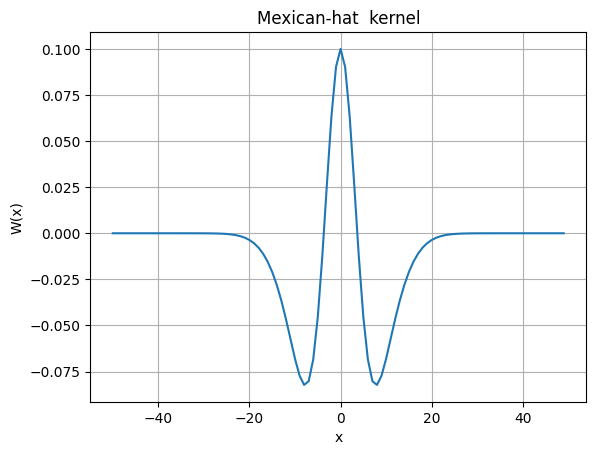

In [ ]:
M = 100
x = np.linspace(-M / 2, M / 2, M, endpoint=False)
A_exc, sigma_exc = 0.3, 5.0
A_inh, sigma_inh = 0.2, 10.0
W = mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh)

fig, ax = plt.subplots()
ax.plot(x, W)
ax.set_xlabel("x")
ax.set_ylabel("W(x)")
ax.set_title("Mexican-hat kernel")
ax.grid(True)
plt.show()

### Ex. 0.3 — Biology

The mexican-hat kernel is supposed to represent the fact that nearby neurons excite each other whilst neurons further away are inhibited. This means that local excitation can be amplified with longer range inhibition stabilizing the network.


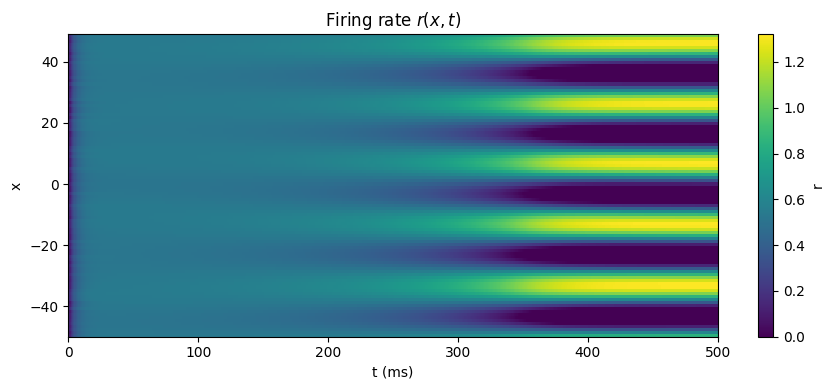

In [ ]:
tau = 10.0 
dt = 1.0
T = 500
n_steps = int(T / dt)
B = 1.0

def run_ring_attractor(seed, M=M, W=W, tau=tau, dt=dt, n_steps=n_steps, B=B):
    rng = np.random.default_rng(seed)
    s = rng.uniform(0.0, 0.1, M)
    r_hist = np.empty((n_steps, M))
    for k in range(n_steps):
        r = np.maximum(0.0, s)
        r_hist[k] = r
        Irec = convolve1d(r, W, mode="wrap")
        s = s + dt * (-s + Irec + B) / tau
    return r_hist

r_hist = run_ring_attractor(67)

t_ms = np.arange(n_steps) * dt

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(
    r_hist.T,
    aspect="auto",
    origin="lower",
    extent=(0, T, x.min(), x.max()),
    interpolation="nearest",
)
ax.set_xlabel("t (ms)")
ax.set_ylabel("x")
ax.set_title(r"Firing rate $r(x,t)$")
plt.colorbar(im, ax=ax, label="r")
plt.tight_layout()
plt.show()

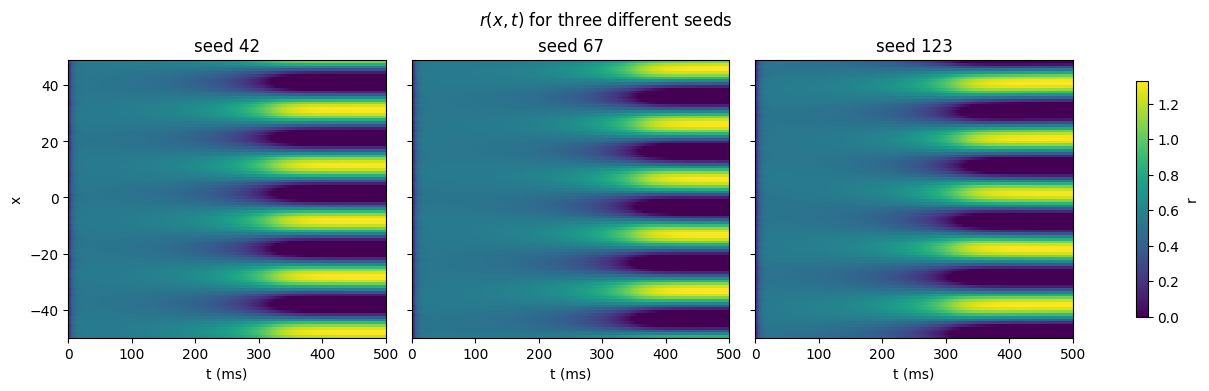

In [ ]:
seeds = [42, 67, 123]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True, constrained_layout=True)
im = None
for ax, seed in zip(axes, seeds):
    rh = run_ring_attractor(seed)
    im = ax.imshow(
        rh.T,
        aspect="auto",
        origin="lower",
        extent=(0, T, x.min(), x.max()),
        interpolation="nearest",
    )
    ax.set_xlabel("t (ms)")
    ax.set_title(f"seed {seed}")
axes[0].set_ylabel("x")
fig.suptitle(r"$r(x,t)$ for three different seeds")
fig.colorbar(im, ax=list(axes), shrink=0.85, label="r")
plt.show()

### Ex. 0.5 — Behavior and dependence on initialization

With Mexican-hat weights on a ring the activity does not stay uniform; you get localized bumps instead of a flat profile (continuous attractor). Different seeds look similar in broad strokes (bumps stabilize after a short transient) but differ in where the bump sits and in the early dynamics, which is what you expect on a ring with many equivalent positions. Same kind of state, not the same exact spatial pattern.

## Exercise 1 — 1D Velocity Integration

### Ex. 1.1

In [ ]:
B0 = 1.5
alpha = 0.5
l = 1.0
T = 1000
dt = 1.0
n_steps = int(T / dt)


W_R = mexican_hat_1d(x - l, A_exc, sigma_exc, A_inh, sigma_inh)
W_L = mexican_hat_1d(x + l, A_exc, sigma_exc, A_inh, sigma_inh)


def velocity(t):
    if 300 <= t <= 700:
        return 1.0
    else:
        return 0.0


def run_two_population_integrator(seed):
    rng = np.random.default_rng(seed)

    s_R = rng.uniform(0.0, 0.1, M)
    s_L = rng.uniform(0.0, 0.1, M)

    rtotal_hist = np.empty((n_steps, M))

    for k in range(n_steps):
        t = k * dt
        v = velocity(t)

        B_R = B0 * (1 + alpha * v)
        B_L = B0 * (1 - alpha * v)

        r_R = np.maximum(0.0, s_R)
        r_L = np.maximum(0.0, s_L)

        rtotal_hist[k] = r_R + r_L

        Irec = convolve1d(r_R, W_R, mode="wrap") + convolve1d(r_L, W_L, mode="wrap")

        s_R = s_R + dt * (-s_R + Irec + B_R) / tau
        s_L = s_L + dt * (-s_L + Irec + B_L) / tau

    return rtotal_hist


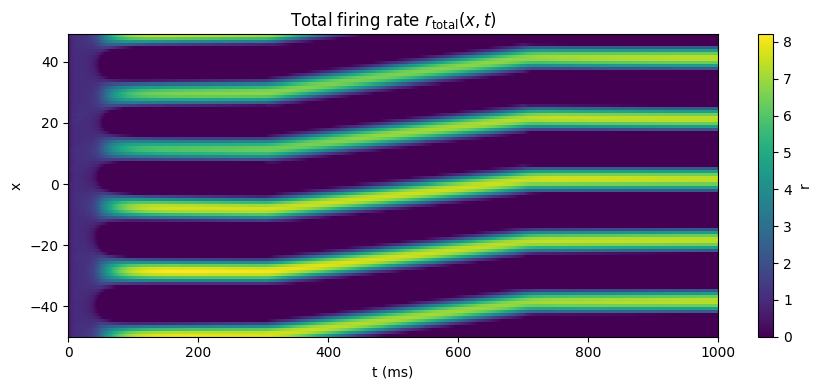

In [ ]:
rtotal_hist = run_two_population_integrator(67)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(
    rtotal_hist.T,
    aspect="auto",
    origin="lower",
    extent=(0, T, x.min(), x.max()),
    interpolation="nearest",
)
ax.set_xlabel("t (ms)")
ax.set_ylabel("x")
ax.set_title(r"Total firing rate $r_{\mathrm{total}}(x,t)$")
plt.colorbar(im, ax=ax, label="r")
plt.tight_layout()
plt.show()

We observe that when v=0, the network converges to stable bumps. When v=1.0 between 300 ms and 700 ms, these bumps move steadily in the same direction. Finally, when v=0 again after 700 ms, the bumps stabilize at their new positions.

### Ex. 1.2

R and L get the same recurrent input but different baselines, \(B_R = B_0(1+\alpha v)\) and \(B_L = B_0(1-\alpha v)\). When \(v \neq 0\) one population is driven harder, and because their Mexican-hat kernels are shifted in opposite directions along the ring, that imbalance nudges the shared bump pattern to drift. When \(v\) goes back to zero the inputs become symmetric again so the drift stops (up to small fluctuations).

### Ex. 1.3

In [ ]:
def run_two_population_integrator_varying(seed):
    rng = np.random.default_rng(seed)

    velocities = np.concatenate([rng.uniform(-2, -0.5, 5), rng.uniform(0.5, 2, 5)])
    rng.shuffle(velocities)
    v_t = np.repeat(velocities, 300)

    n_steps = len(v_t)
    T = n_steps * dt

    s_R = rng.uniform(0.0, 0.1, M)
    s_L = rng.uniform(0.0, 0.1, M)

    rtotal_hist = np.empty((n_steps, M))

    for k in range(n_steps):
        v = v_t[k]

        B_R = B0 * (1 + alpha * v)
        B_L = B0 * (1 - alpha * v)

        r_R = np.maximum(0.0, s_R)
        r_L = np.maximum(0.0, s_L)

        r_total = r_R + r_L
        rtotal_hist[k] = r_total

        Irec = convolve1d(r_R, W_R, mode="wrap") + convolve1d(r_L, W_L, mode="wrap")

        s_R = s_R + dt * (-s_R + Irec + B_R) / tau
        s_L = s_L + dt * (-s_L + Irec + B_L) / tau

    return rtotal_hist, v_t, n_steps

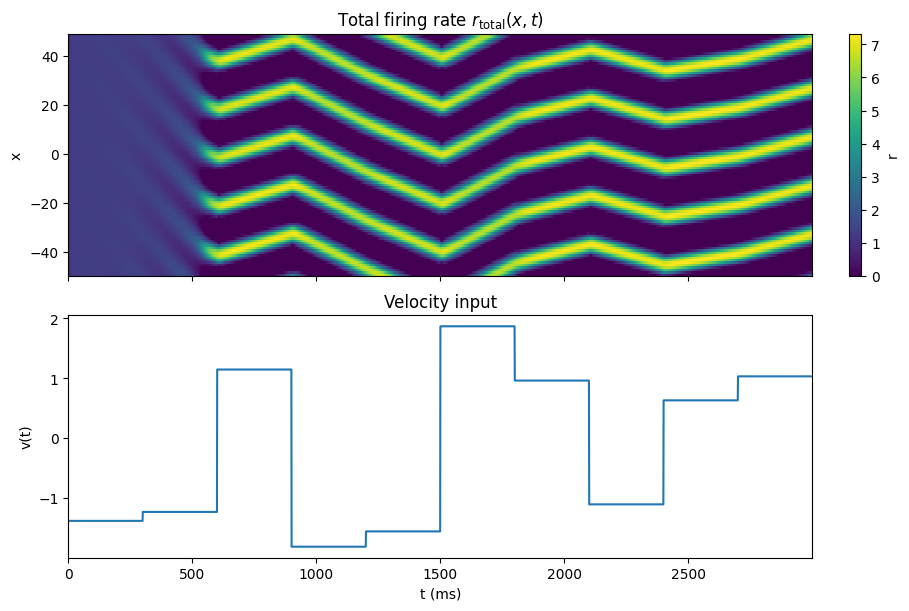

In [ ]:
rtotal_hist, v_t, n_steps = run_two_population_integrator_varying(67)

t_ms = np.arange(n_steps) * dt

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, constrained_layout=True)

im = axes[0].imshow(
    rtotal_hist.T,
    aspect="auto",
    origin="lower",
    extent=(0, t_ms[-1], x.min(), x.max()),
    interpolation="nearest",
)
axes[0].set_ylabel("x")
axes[0].set_title(r"Total firing rate $r_{\mathrm{total}}(x,t)$")
fig.colorbar(im, ax=axes[0], label="r")

axes[1].plot(t_ms, v_t)
axes[1].set_xlabel("t (ms)")
axes[1].set_ylabel("v(t)")
axes[1].set_title("Velocity input")

plt.show()

We observe that the bumps closely follow the variations of the velocity. Their direction changes when the sign of the velocity v changes, and their drift speed increases with ∣v∣. This confirms that the bump acts as a velocity integrator.

### Ex. 1.4

Idea of the method:
1. Compute the position of the bump $x_{bump}$ as the location of the maximum of the total activity
2. Correct for the circular structure of the network when the bump crosses the boundary
3. Compute the drift velocity using finite differences: $v_{drift}(t) = x_{bump}(t+1) - x_{bump}(t)$

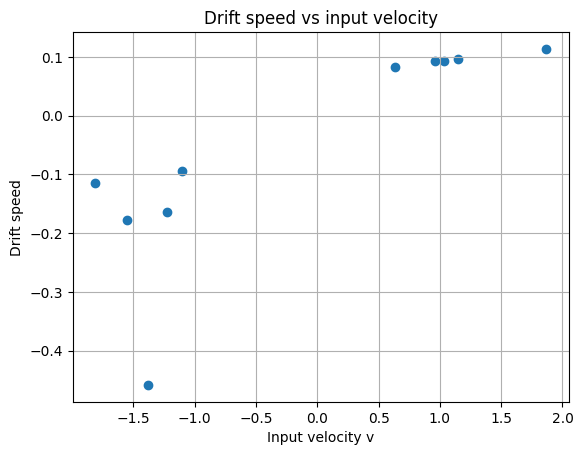

In [ ]:
x_bump = np.argmax(rtotal_hist, axis=1).astype(float)

for t in range(1, len(x_bump)):
    diff = x_bump[t] - x_bump[t-1]
    if diff > M/2:
        x_bump[t:] -= M
    elif diff < -M/2:
        x_bump[t:] += M


v_drift = np.diff(x_bump)


block_size = 300
input_velocities = []
measured_speeds = []

for i in range(len(v_t)//block_size):
    start = i * block_size
    end = (i+1) * block_size

    input_velocities.append(np.mean(v_t[start:end]))
    measured_speeds.append(np.mean(v_drift[start:end-1]))



plt.scatter(input_velocities, measured_speeds)
plt.xlabel("Input velocity v")
plt.ylabel("Drift speed")
plt.title("Drift speed vs input velocity")
plt.grid()
plt.show()

The measured drift velocity generally follows the input velocity: it is positive for v > 0 and negative for v < 0. The relationship appears to be roughly linear, although it is not perfect due to a few outliers and numerical variability. The network therefore accurately reproduces the expected behavior of a velocity integrator.

## Exercise 2 — Extending to 2D Grid Cells

### Ex. 2.1

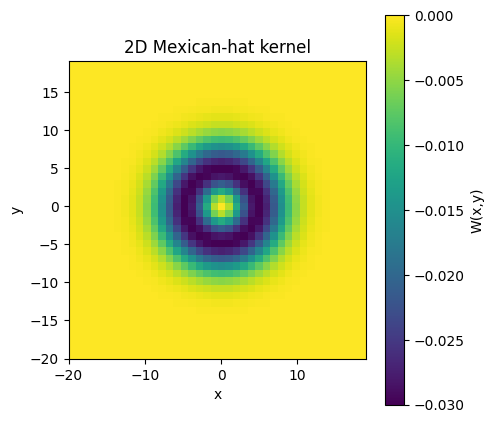

In [ ]:
def mexican_hat_2d(X, Y, A_exc, sigma_exc, A_inh, sigma_inh):
    R2 = X**2 + Y**2
    return A_exc * np.exp(-R2 / sigma_exc**2) - A_inh * np.exp(-R2 / sigma_inh**2)

M2 = 40
x2 = np.linspace(-M2 / 2, M2 / 2, M2, endpoint=False)
X, Y = np.meshgrid(x2, x2, indexing="xy")

A_exc_2d, A_inh_2d = 1, 1
sigma_exc_2d, sigma_inh_2d = 4.8, 5

W2 = mexican_hat_2d(X, Y, A_exc_2d, sigma_exc_2d, A_inh_2d, sigma_inh_2d)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(W2, origin="lower", extent=(x2.min(), x2.max(), x2.min(), x2.max()))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D Mexican-hat kernel")
plt.colorbar(im, ax=ax, label="W(x,y)")
plt.tight_layout()
plt.show()

### Ex. 2.2

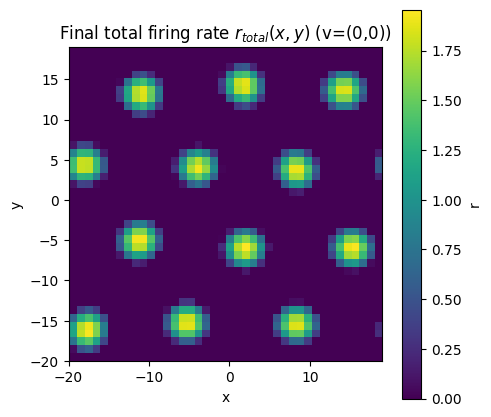

In [ ]:
tau2 = 10
dt2 = 1
l2 = 1
alpha2 = 0.1
B0_2 = 1

W_N = np.roll(W2, -l2, axis=1)
W_S = np.roll(W2, l2, axis=1)
W_E = np.roll(W2, -l2, axis=0)
W_W = np.roll(W2, l2, axis=0)

def run_2d_grid(vx_t, vy_t, seed=67):
    rng = np.random.default_rng(seed)
    n_steps = len(vx_t)

    sN = rng.uniform(0.0, 0.1, (M2, M2))
    sS = rng.uniform(0.0, 0.1, (M2, M2))
    sE = rng.uniform(0.0, 0.1, (M2, M2))
    sW = rng.uniform(0.0, 0.1, (M2, M2))

    rtotal_hist = np.empty((n_steps, M2, M2))

    for k in range(n_steps):
        vx = vx_t[k]
        vy = vy_t[k]

        BN = B0_2 * (1 + alpha2 * vy)
        BS = B0_2 * (1 - alpha2 * vy)
        BE = B0_2 * (1 + alpha2 * vx)
        BW = B0_2 * (1 - alpha2 * vx)

        rN = np.maximum(0.0, sN)
        rS = np.maximum(0.0, sS)
        rE = np.maximum(0.0, sE)
        rW = np.maximum(0.0, sW)

        rtotal_hist[k] = rN + rS + rE + rW

        Irec = (
            convolve(rN, W_N, mode="wrap")
            + convolve(rS, W_S, mode="wrap")
            + convolve(rE, W_E, mode="wrap")
            + convolve(rW, W_W, mode="wrap")
        )

        sN = sN + dt2 * (-sN + Irec + BN) / tau2
        sS = sS + dt2 * (-sS + Irec + BS) / tau2
        sE = sE + dt2 * (-sE + Irec + BE) / tau2
        sW = sW + dt2 * (-sW + Irec + BW) / tau2

    return rtotal_hist

T_stab = 400
n_stab = int(T_stab / dt2)
vx_0 = np.zeros(n_stab)
vy_0 = np.zeros(n_stab)

rtotal_hist_2d = run_2d_grid(vx_0, vy_0, seed=67)
r_final = rtotal_hist_2d[-1]

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(r_final, origin="lower", extent=(x2.min(), x2.max(), x2.min(), x2.max()))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"Final total firing rate $r_{total}(x,y)$ (v=(0,0))")
plt.colorbar(im, ax=ax, label="r")
plt.tight_layout()
plt.show()

With periodic boundary conditions and zero velocity input, the activity converges to a stable multi-bump pattern over the 2D sheet. The resulting pattern exhibits approximately regular spacing, consistent with a grid-like attractor structure.

### Ex. 2.3

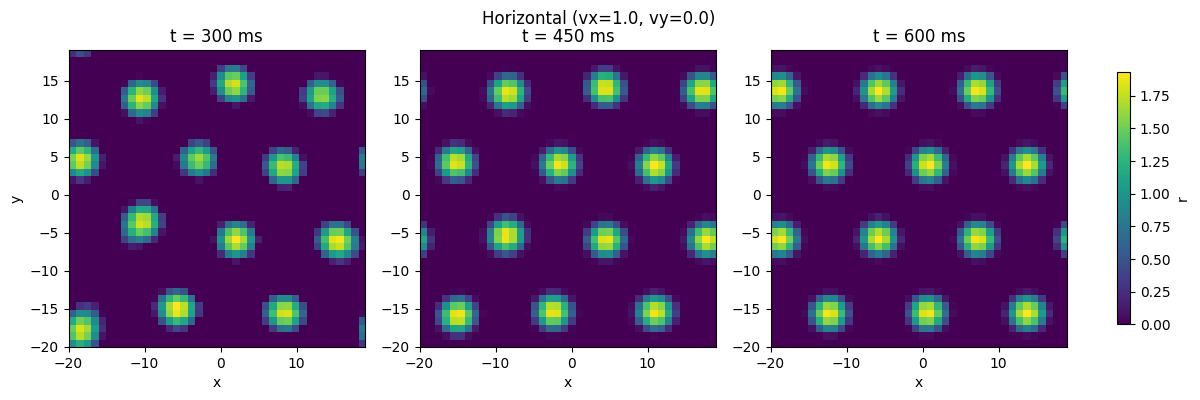

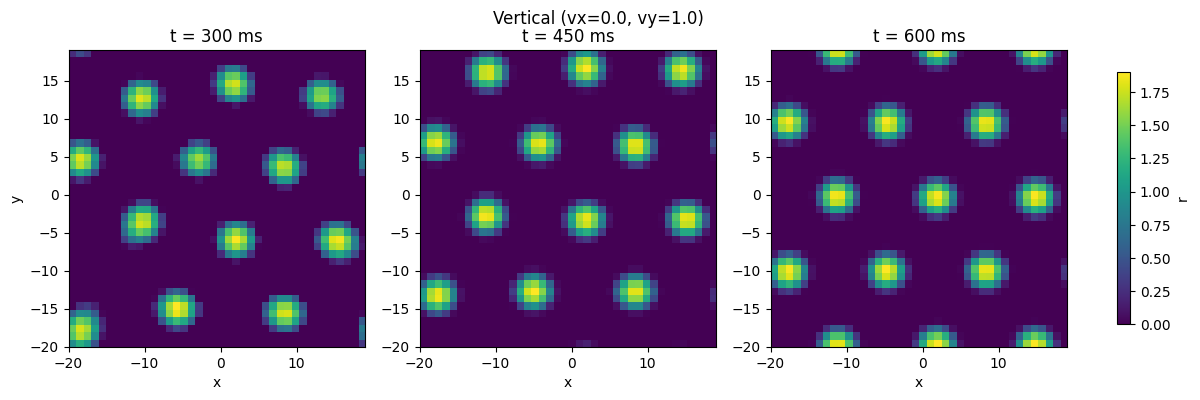

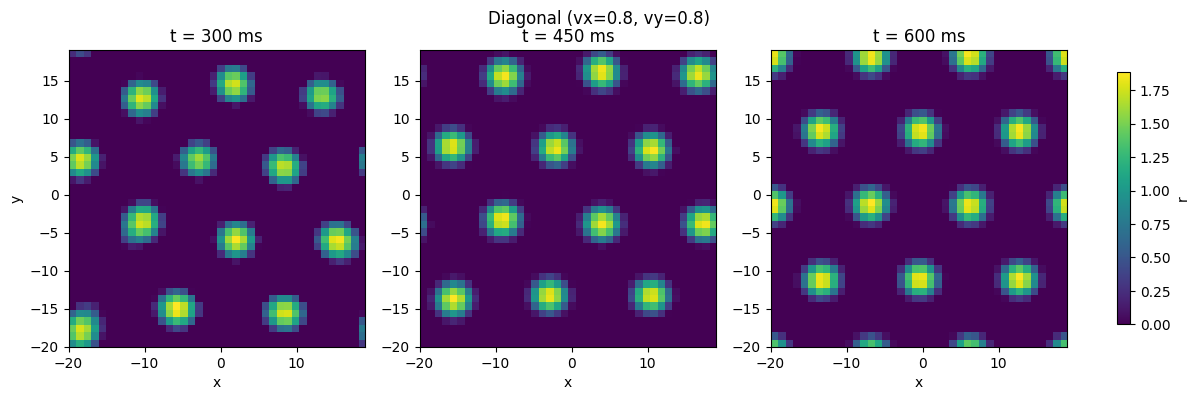

In [ ]:
def run_direction_trial(vx_const, vy_const, pre_ms=300, move_ms=300):
    n_pre = int(pre_ms / dt2)
    n_move = int(move_ms / dt2)
    vx_t = np.concatenate([np.zeros(n_pre), np.full(n_move, vx_const)])
    vy_t = np.concatenate([np.zeros(n_pre), np.full(n_move, vy_const)])
    r_hist = run_2d_grid(vx_t, vy_t, seed=67)
    return r_hist, [n_pre, n_pre + n_move // 2, n_pre + n_move - 1]

trials = [
    (1, 0, "Horizontal (vx=1.0, vy=0.0)"),
    (0, 1, "Vertical (vx=0.0, vy=1.0)"),
    (0.8, 0.8, "Diagonal (vx=0.8, vy=0.8)"),
]

for vx_c, vy_c, title in trials:
    r_hist, ts = run_direction_trial(vx_c, vy_c, pre_ms=300, move_ms=300)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
    for ax, t_idx, t_lab in zip(axes, ts, [300, 450, 600]):
        im = ax.imshow(
            r_hist[t_idx],
            origin="lower",
            extent=(x2.min(), x2.max(), x2.min(), x2.max()),
        )
        ax.set_title(f"t = {t_lab} ms")
        ax.set_xlabel("x")
    axes[0].set_ylabel("y")
    fig.suptitle(title)
    fig.colorbar(im, ax=axes, shrink=0.85, label="r")
    plt.show()

For horizontal input, the 2D bump lattice translates primarily along the x-axis; for vertical input, it translates along y; and for diagonal input, it shifts along both axes. Across directions, the pattern keeps a similar shape while its position drifts continuously, consistent with 2D path-integration behavior.